# 04 - 优化基础：把“知道方向”变成“真的学会”

在上一节微积分中，我们已经看到：梯度告诉我们函数上升最快的方向。优化要解决的问题是：

> 如果损失函数 $L(\theta)$ 衡量模型有多差，怎样一步步调整参数 $\theta$，让损失越来越小？

本 notebook 不只是把 `04_optimization.py` 改成 Notebook，而是重新组织成适合学习的交互式教程，并补充更多图表、直觉和实验。

## 学习目标

学完本节你应该能够：

1. 解释梯度下降的更新公式为什么是 $\theta \leftarrow \theta - \eta \nabla L(\theta)$。
2. 用图像判断学习率过小、合适、过大时的现象。
3. 区分 Batch GD、SGD 和 Mini-batch SGD 的计算方式与噪声特点。
4. 理解 Momentum 如何在“狭长峡谷”中加速并减少震荡。
5. 从零实现 Adam，并解释一阶矩、二阶矩和偏差修正的作用。
6. 画出常见学习率调度曲线，并知道它们适合什么场景。
7. 用优化器训练一个简单线性回归模型。

## 本节路线图

| 章节 | 关键词 | 核心问题 |
|---|---|---|
| §1 | 目标函数、参数、损失地形 | 优化到底在找什么？ |
| §2 | 梯度下降 | 为什么沿负梯度方向走？ |
| §3 | 学习率 | 步子大小如何影响收敛？ |
| §4 | 批量、随机、小批量 | 为什么深度学习不用全量梯度？ |
| §5 | Momentum | 如何减少震荡、加速前进？ |
| §6 | Adam / AdamW | 为什么 Adam 这么常用？ |
| §7 | 学习率调度 | 为什么训练后期要减速？ |
| §8 | 小项目 | 用优化器拟合线性模型 |


In [1]:
# 环境准备
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(42)
plt.rcParams['figure.figsize'] = (8, 5)
plt.rcParams['axes.grid'] = True
plt.rcParams['font.sans-serif'] = ['DejaVu Sans']
plt.rcParams['axes.unicode_minus'] = False

print("NumPy version:", np.__version__)
print("环境准备完成")


NumPy version: 2.2.6
环境准备完成


## 1. 优化问题的基本形式

机器学习中的训练通常可以写成一个优化问题：

$$
\theta^* = \arg\min_\theta L(\theta)
$$

其中：

- $\theta$：模型参数，例如线性回归中的权重 $w$ 和偏置 $b$；
- $L(\theta)$：损失函数，衡量模型预测与真实标签的差距；
- $\theta^*$：让损失最小的参数。

一个非常简单的一维例子是：

$$
f(x) = (x - 3)^2 + 1
$$

它的最低点在 $x=3$，最小值是 $1$。我们先从这个函数入手，因为它足够简单，可以清楚看见优化器每一步在做什么。


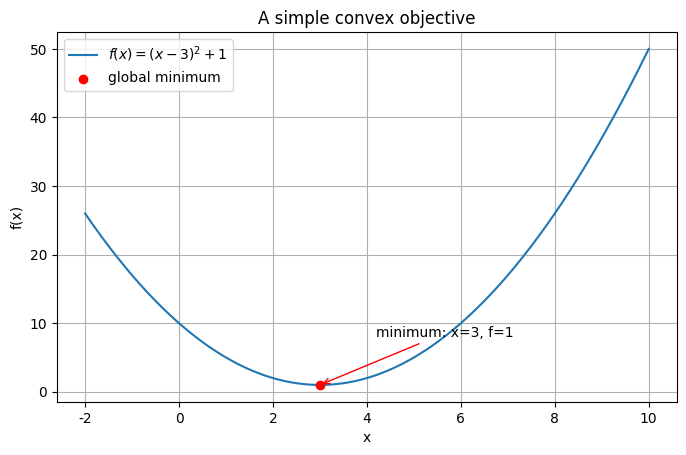

In [2]:
def f_1d(x):
    """目标函数：最小值在 x=3。"""
    return (x - 3) ** 2 + 1

def grad_f_1d(x):
    """f'(x) = 2(x - 3)。"""
    return 2 * (x - 3)

xs = np.linspace(-2, 10, 400)
ys = f_1d(xs)

plt.figure(figsize=(8, 4.8))
plt.plot(xs, ys, label=r"$f(x)=(x-3)^2+1$")
plt.scatter([3], [1], color='red', zorder=3, label='global minimum')
plt.annotate('minimum: x=3, f=1', xy=(3, 1), xytext=(4.2, 8),
             arrowprops=dict(arrowstyle='->', color='red'))
plt.xlabel('x')
plt.ylabel('f(x)')
plt.title('A simple convex objective')
plt.legend()
plt.show()


### 1.1 梯度为什么指向“上坡”？

导数 $f'(x)$ 表示函数在当前位置的斜率：

- 如果 $f'(x)>0$，往右走函数会上升；要下降就应该往左走。
- 如果 $f'(x)<0$，往右走函数会下降；要下降就应该往右走。
- 如果 $f'(x)=0$，局部看起来已经没有斜坡，可能到达极值点或鞍点。

所以，下降方向是导数的反方向。对于多维参数，就是梯度的反方向：

$$
\theta_{t+1}=\theta_t-\eta\nabla L(\theta_t)
$$

其中 $\eta$ 是学习率（learning rate），控制每一步走多远。


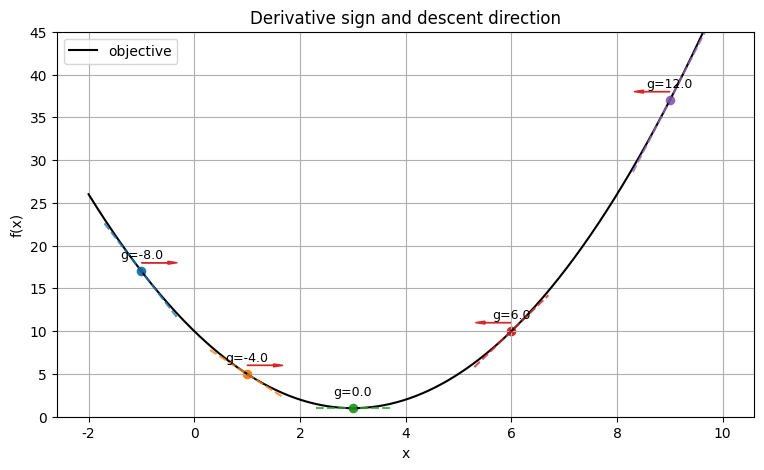

In [3]:
# 在不同位置画出切线，观察梯度符号与下降方向
points = [-1, 1, 3, 6, 9]
xs = np.linspace(-2, 10, 400)

plt.figure(figsize=(9, 5))
plt.plot(xs, f_1d(xs), color='black', label='objective')

for x0 in points:
    y0 = f_1d(x0)
    g = grad_f_1d(x0)
    local_x = np.linspace(x0 - 0.7, x0 + 0.7, 30)
    tangent = y0 + g * (local_x - x0)
    plt.plot(local_x, tangent, '--', alpha=0.8)
    plt.scatter([x0], [y0], s=35)
    direction = -np.sign(g) if abs(g) > 1e-12 else 0
    if direction != 0:
        plt.arrow(x0, y0 + 1.0, 0.5 * direction, 0,
                  head_width=0.35, head_length=0.18, color='tab:red')
    plt.text(x0, y0 + 1.5, f"g={g:.1f}", ha='center', fontsize=9)

plt.title('Derivative sign and descent direction')
plt.xlabel('x')
plt.ylabel('f(x)')
plt.ylim(0, 45)
plt.legend()
plt.show()


## 2. 梯度下降：把公式变成轨迹

梯度下降算法可以写成四步：

1. 初始化参数，例如 $x_0=10$。
2. 计算当前位置的梯度 $g_t=f'(x_t)$。
3. 更新参数 $x_{t+1}=x_t-\eta g_t$。
4. 重复直到损失足够小或达到最大步数。

下面实现一个可复用的一维梯度下降函数，并记录每一步的轨迹。


In [4]:
def gradient_descent_1d(f, grad, x0, lr=0.1, steps=30):
    """一维梯度下降，返回每一步的 x、loss 和 gradient。"""
    x = float(x0)
    history = []
    for step in range(steps + 1):
        loss = f(x)
        g = grad(x)
        history.append({'step': step, 'x': x, 'loss': loss, 'grad': g})
        if step < steps:
            x = x - lr * g
    return history

history = gradient_descent_1d(f_1d, grad_f_1d, x0=10, lr=0.1, steps=35)

print(f"{'step':>4} {'x':>10} {'f(x)':>10} {'grad':>10}")
print('-' * 42)
for row in history[:8] + history[-5:]:
    print(f"{row['step']:>4} {row['x']:>10.4f} {row['loss']:>10.4f} {row['grad']:>10.4f}")

final = history[-1]
print('\n最终结果：')
print(f"x = {final['x']:.6f}, f(x) = {final['loss']:.6f}")
print("真实最小值：x = 3, f(x) = 1")


step          x       f(x)       grad
------------------------------------------
   0    10.0000    50.0000    14.0000
   1     8.6000    32.3600    11.2000
   2     7.4800    21.0704     8.9600
   3     6.5840    13.8451     7.1680
   4     5.8672     9.2208     5.7344
   5     5.2938     6.2613     4.5875
   6     4.8350     4.3673     3.6700
   7     4.4680     3.1550     2.9360
  31     3.0069     1.0000     0.0139
  32     3.0055     1.0000     0.0111
  33     3.0044     1.0000     0.0089
  34     3.0035     1.0000     0.0071
  35     3.0028     1.0000     0.0057

最终结果：
x = 3.002840, f(x) = 1.000008
真实最小值：x = 3, f(x) = 1


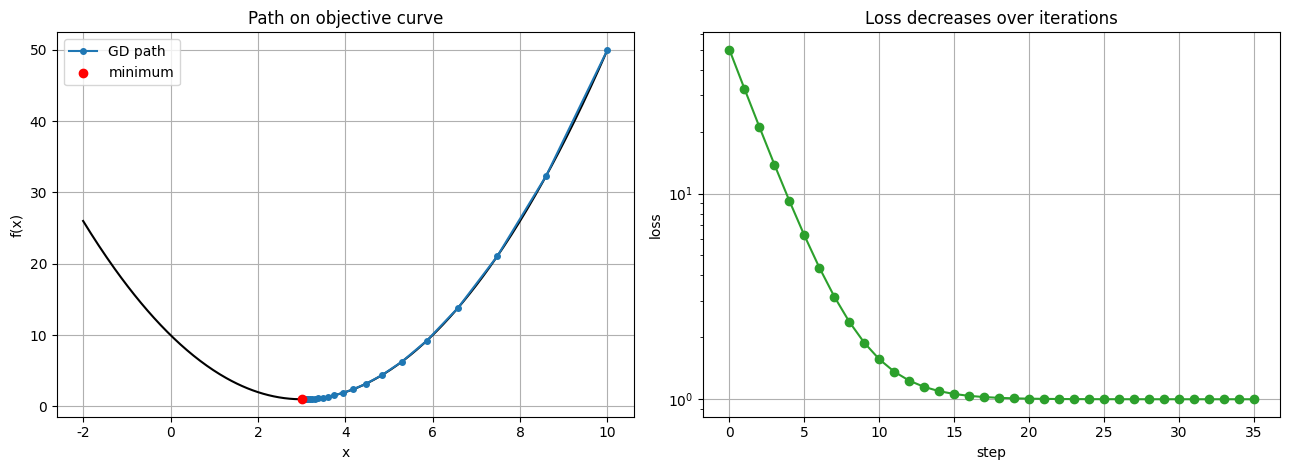

In [5]:
# 可视化梯度下降路径
xs = np.linspace(-2, 10, 400)
path_x = np.array([h['x'] for h in history])
path_y = f_1d(path_x)

fig, axes = plt.subplots(1, 2, figsize=(13, 4.8))

axes[0].plot(xs, f_1d(xs), color='black')
axes[0].plot(path_x, path_y, 'o-', color='tab:blue', markersize=4, label='GD path')
axes[0].scatter([3], [1], color='red', zorder=3, label='minimum')
axes[0].set_title('Path on objective curve')
axes[0].set_xlabel('x')
axes[0].set_ylabel('f(x)')
axes[0].legend()

axes[1].plot([h['step'] for h in history], [h['loss'] for h in history], 'o-', color='tab:green')
axes[1].set_title('Loss decreases over iterations')
axes[1].set_xlabel('step')
axes[1].set_ylabel('loss')
axes[1].set_yscale('log')

plt.tight_layout()
plt.show()


## 3. 学习率：优化中最重要的旋钮

学习率 $\eta$ 决定每次更新的步长：

$$
x_{t+1}=x_t-\eta f'(x_t)
$$

在 $f(x)=(x-3)^2+1$ 这个二次函数上，可以直接看出学习率的影响：

- $\eta$ 太小：每一步很谨慎，稳定但很慢。
- $\eta$ 合适：快速靠近最小值。
- $\eta$ 太大：越过最低点后反复震荡。
- $\eta$ 超过稳定范围：震荡幅度越来越大，最终发散。

对这个函数，更新公式是：

$$
x_{t+1}-3=(1-2\eta)(x_t-3)
$$

要收敛，需要 $|1-2\eta|<1$，即 $0<\eta<1$。这解释了为什么 $\eta=1$ 会在两侧来回跳，而 $\eta>1$ 会发散。


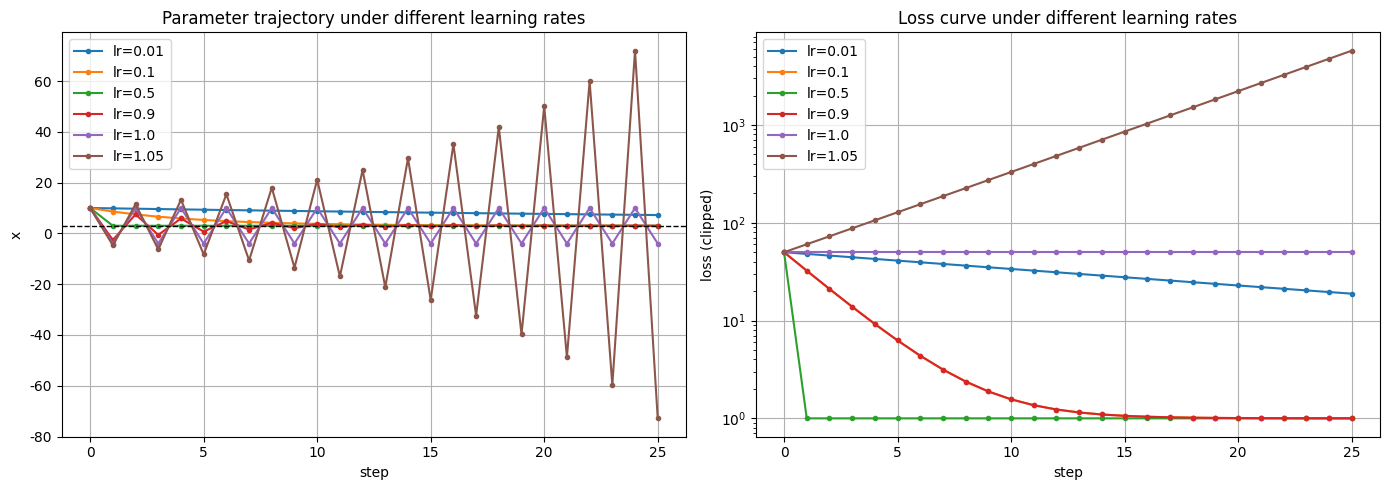

    lr   x after 25 steps           loss       status
--------------------------------------------------------
  0.01            7.22425       18.84431    slow/near
  0.10            3.02645        1.00070    slow/near
  0.50            3.00000        1.00000    converged
  0.90            2.97355        1.00070    slow/near
  1.00           -4.00000       50.00000  oscillating
  1.05          -72.84294     5753.15179  oscillating


In [6]:
learning_rates = [0.01, 0.1, 0.5, 0.9, 1.0, 1.05]
results = {}

for lr in learning_rates:
    hist = gradient_descent_1d(f_1d, grad_f_1d, x0=10, lr=lr, steps=25)
    results[lr] = hist

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for lr, hist in results.items():
    steps = [h['step'] for h in hist]
    x_values = [h['x'] for h in hist]
    losses = [min(h['loss'], 1e5) for h in hist]  # 截断只是为了图像可读
    axes[0].plot(steps, x_values, marker='o', markersize=3, label=f'lr={lr}')
    axes[1].plot(steps, losses, marker='o', markersize=3, label=f'lr={lr}')

axes[0].axhline(3, color='black', linestyle='--', linewidth=1)
axes[0].set_title('Parameter trajectory under different learning rates')
axes[0].set_xlabel('step')
axes[0].set_ylabel('x')
axes[0].legend()

axes[1].set_title('Loss curve under different learning rates')
axes[1].set_xlabel('step')
axes[1].set_ylabel('loss (clipped)')
axes[1].set_yscale('log')
axes[1].legend()

plt.tight_layout()
plt.show()

print(f"{'lr':>6} {'x after 25 steps':>18} {'loss':>14} {'status':>12}")
print('-' * 56)
for lr, hist in results.items():
    x_end = hist[-1]['x']
    loss_end = hist[-1]['loss']
    if not np.isfinite(loss_end) or abs(x_end) > 1e6:
        status = 'diverged'
    elif abs(x_end - 3) < 1e-2:
        status = 'converged'
    elif lr >= 1.0:
        status = 'oscillating'
    else:
        status = 'slow/near'
    print(f"{lr:>6.2f} {x_end:>18.5f} {loss_end:>14.5f} {status:>12}")


### 3.1 二维损失地形：等高线上的路径

真实模型通常有很多参数。为了可视化，我们先看二维函数：

$$
f(x,y)=10x^2+y^2
$$

它像一个狭长的碗：

- $x$ 方向很陡，因为系数是 10；
- $y$ 方向比较平缓；
- 最小值在原点 $(0,0)$。

这类“狭长峡谷”在神经网络训练中很常见，会导致普通梯度下降在陡峭方向上来回震荡。


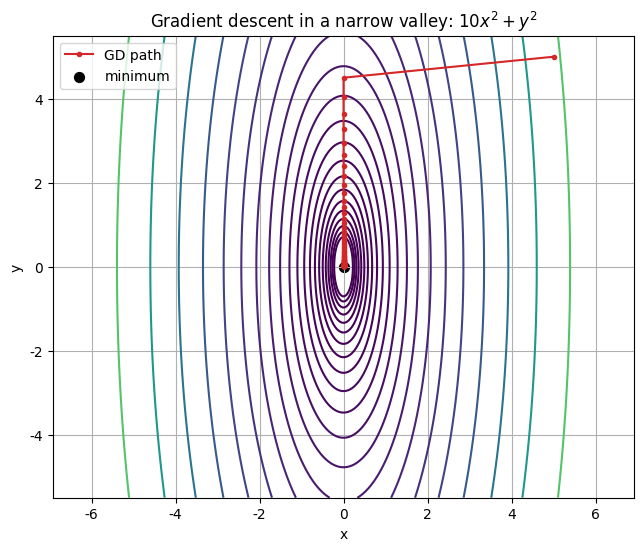

60 步后： [0.         0.00898505] loss = 8.073115044996368e-05


In [7]:
def f_2d(p):
    x, y = p
    return 10 * x**2 + y**2

def grad_2d(p):
    x, y = p
    return np.array([20 * x, 2 * y], dtype=float)

def optimize_path(grad_fn, start, lr, steps, method='sgd', beta=0.9):
    p = np.array(start, dtype=float)
    v = np.zeros_like(p)
    path = [p.copy()]
    for _ in range(steps):
        g = grad_fn(p)
        if method == 'sgd':
            p = p - lr * g
        elif method == 'momentum':
            v = beta * v + (1 - beta) * g
            p = p - lr * v
        else:
            raise ValueError(method)
        path.append(p.copy())
    return np.array(path)

path_sgd = optimize_path(grad_2d, start=[5, 5], lr=0.05, steps=60, method='sgd')

x_grid = np.linspace(-5.5, 5.5, 250)
y_grid = np.linspace(-5.5, 5.5, 250)
Xg, Yg = np.meshgrid(x_grid, y_grid)
Z = 10 * Xg**2 + Yg**2

plt.figure(figsize=(7.5, 6))
levels = np.geomspace(0.5, 400, 22)
plt.contour(Xg, Yg, Z, levels=levels, cmap='viridis')
plt.plot(path_sgd[:, 0], path_sgd[:, 1], 'o-', color='tab:red', markersize=3, label='GD path')
plt.scatter([0], [0], color='black', s=50, label='minimum')
plt.title(r'Gradient descent in a narrow valley: $10x^2+y^2$')
plt.xlabel('x')
plt.ylabel('y')
plt.axis('equal')
plt.legend()
plt.show()

print('60 步后：', path_sgd[-1], 'loss =', f_2d(path_sgd[-1]))


## 4. Batch GD、SGD 与 Mini-batch SGD

训练集有 $n$ 个样本时，平均损失通常写成：

$$
L(\theta)=\frac{1}{n}\sum_{i=1}^n \ell_i(\theta)
$$

不同梯度方法的区别在于：每一步用多少样本估计梯度？

| 方法 | 每次更新用的数据 | 优点 | 缺点 |
|---|---:|---|---|
| Batch Gradient Descent | 全部样本 | 梯度稳定、方向准确 | 大数据时每一步太慢 |
| SGD | 1 个样本 | 每步便宜，有噪声可帮助探索 | 路径很抖，loss 不一定单调下降 |
| Mini-batch SGD | 一小批样本 | 速度和稳定性的折中，最常用 | batch size 需要选择 |

深度学习里说的 “SGD” 很多时候其实指 Mini-batch SGD。


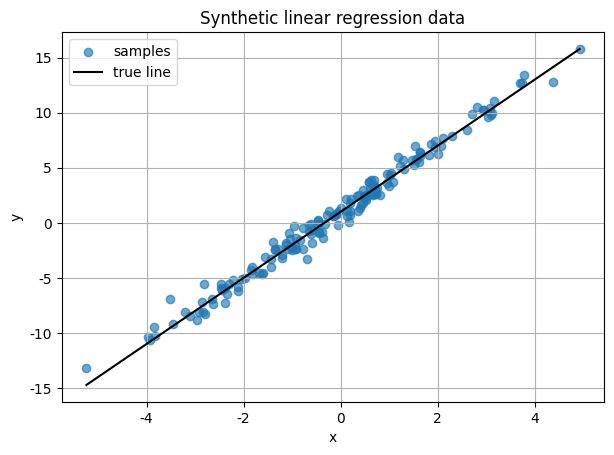

In [8]:
# 构造一个线性回归数据集：y = 3x + 1 + 噪声
np.random.seed(42)
n_samples = 160
X = np.random.randn(n_samples, 1) * 2
w_true, b_true = 3.0, 1.0
y = w_true * X + b_true + np.random.randn(n_samples, 1) * 0.7

plt.figure(figsize=(7, 4.8))
plt.scatter(X[:, 0], y[:, 0], alpha=0.65, label='samples')
line_x = np.linspace(X.min(), X.max(), 100)
plt.plot(line_x, w_true * line_x + b_true, color='black', label='true line')
plt.title('Synthetic linear regression data')
plt.xlabel('x')
plt.ylabel('y')
plt.legend()
plt.show()


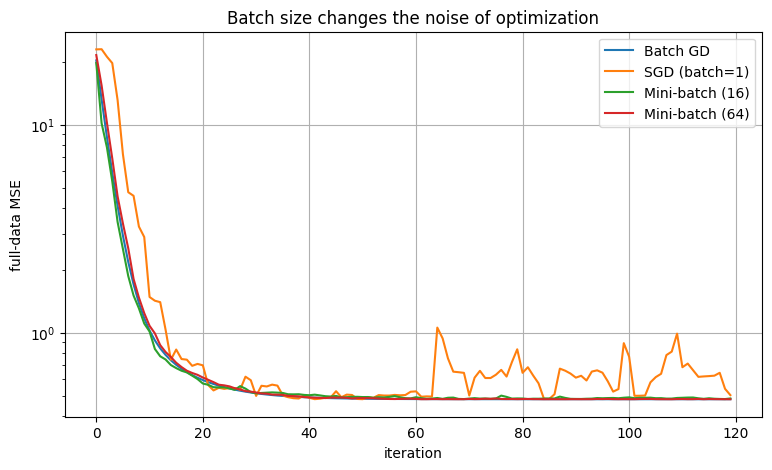

method                     w         b   final loss
----------------------------------------------------
Batch GD              2.9793    1.0606       0.4804
SGD (batch=1)         2.9438    1.1904       0.5028
Mini-batch (16)       2.9451    1.0551       0.4845
Mini-batch (64)       2.9797    1.0680       0.4805
真实参数：w=3.0, b=1.0


In [9]:
def mse_loss(X, y, w, b):
    pred = X * w + b
    return float(np.mean((pred - y) ** 2))

def gradient_on_batch(Xb, yb, w, b):
    pred = Xb * w + b
    error = pred - yb
    dw = 2 * np.mean(error * Xb)
    db = 2 * np.mean(error)
    return float(dw), float(db)

def train_linear_gd(X, y, lr=0.03, steps=120, batch_size=None, seed=0):
    rng = np.random.default_rng(seed)
    w, b = 0.0, 0.0
    losses = []
    params = []
    n = len(X)
    for step in range(steps):
        if batch_size is None:          # Batch GD
            Xb, yb = X, y
        elif batch_size == 1:           # SGD
            idx = rng.choice(n, size=1, replace=False)
            Xb, yb = X[idx], y[idx]
        else:                           # Mini-batch SGD
            idx = rng.choice(n, size=batch_size, replace=False)
            Xb, yb = X[idx], y[idx]
        dw, db = gradient_on_batch(Xb, yb, w, b)
        w -= lr * dw
        b -= lr * db
        losses.append(mse_loss(X, y, w, b))  # 为了公平，用全量 loss 评估
        params.append((w, b))
    return np.array(params), np.array(losses)

configs = {
    'Batch GD': None,
    'SGD (batch=1)': 1,
    'Mini-batch (16)': 16,
    'Mini-batch (64)': 64,
}

training = {}
for name, bs in configs.items():
    params, losses = train_linear_gd(X, y, lr=0.03, steps=120, batch_size=bs, seed=123)
    training[name] = (params, losses)

plt.figure(figsize=(9, 5))
for name, (_, losses) in training.items():
    plt.plot(losses, label=name)
plt.yscale('log')
plt.xlabel('iteration')
plt.ylabel('full-data MSE')
plt.title('Batch size changes the noise of optimization')
plt.legend()
plt.show()

print(f"{'method':<18} {'w':>9} {'b':>9} {'final loss':>12}")
print('-' * 52)
for name, (params, losses) in training.items():
    w, b = params[-1]
    print(f"{name:<18} {w:>9.4f} {b:>9.4f} {losses[-1]:>12.4f}")
print(f"真实参数：w={w_true}, b={b_true}")


### 4.1 梯度噪声：随机性既是缺点也是优点

Mini-batch 的梯度是全量梯度的估计。batch 越小，估计越 noisy；batch 越大，估计越接近全量梯度。

这不是纯粹的坏事：

- 噪声会让 loss 曲线不那么平滑；
- 但适量噪声有时可以帮助优化器离开很差的局部区域；
- 大 batch 更适合硬件并行，但可能需要更精细的学习率调度。

下面固定同一个参数点，重复采样不同 batch，观察梯度估计的分布。


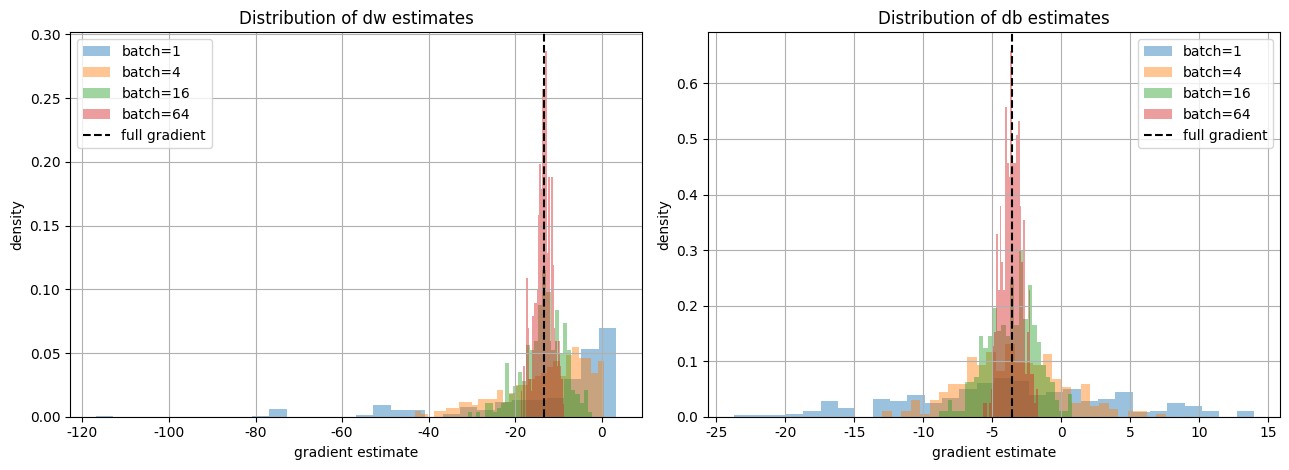

全量梯度：dw = -13.3158, db = -3.5875


In [10]:
# 在同一个参数点估计梯度分布
w0, b0 = 1.0, -1.0
full_grad = gradient_on_batch(X, y, w0, b0)

rng = np.random.default_rng(7)
batch_sizes = [1, 4, 16, 64]
num_trials = 300

fig, axes = plt.subplots(1, 2, figsize=(13, 4.8))

for bs in batch_sizes:
    grads = []
    for _ in range(num_trials):
        idx = rng.choice(len(X), size=bs, replace=False)
        grads.append(gradient_on_batch(X[idx], y[idx], w0, b0))
    grads = np.array(grads)
    axes[0].hist(grads[:, 0], bins=30, alpha=0.45, density=True, label=f'batch={bs}')
    axes[1].hist(grads[:, 1], bins=30, alpha=0.45, density=True, label=f'batch={bs}')

axes[0].axvline(full_grad[0], color='black', linestyle='--', label='full gradient')
axes[1].axvline(full_grad[1], color='black', linestyle='--', label='full gradient')
axes[0].set_title('Distribution of dw estimates')
axes[1].set_title('Distribution of db estimates')
for ax in axes:
    ax.legend()
    ax.set_xlabel('gradient estimate')
    ax.set_ylabel('density')
plt.tight_layout()
plt.show()

print('全量梯度：dw = {:.4f}, db = {:.4f}'.format(*full_grad))


## 5. Momentum：给梯度下降加上“惯性”

普通梯度下降只看当前梯度：

$$
\theta_t = \theta_{t-1} - \eta g_t
$$

Momentum 会维护一个速度 $v_t$，让过去的梯度也影响当前更新：

$$
v_t = \beta v_{t-1} + (1-\beta)g_t
$$

$$
\theta_t = \theta_{t-1} - \eta v_t
$$

直觉：像一个球在山谷中滚动。

- 如果很多步的梯度方向一致，速度会累积，前进更快。
- 如果某个方向来回震荡，正负梯度会互相抵消，震荡变小。
- $\beta$ 越大，历史影响越强；常见值是 0.9。


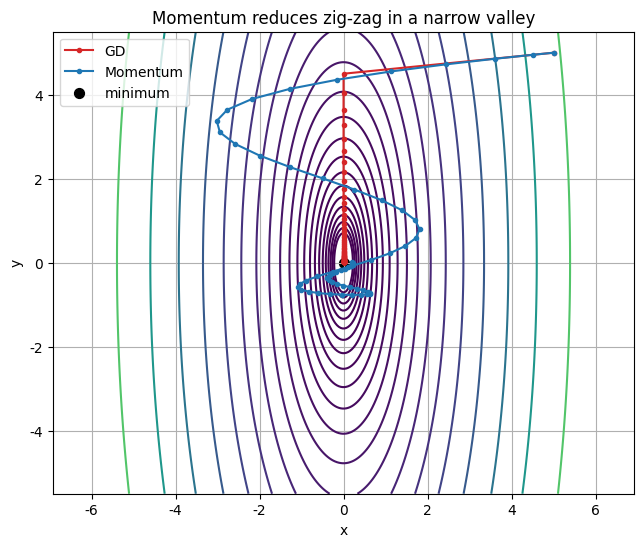

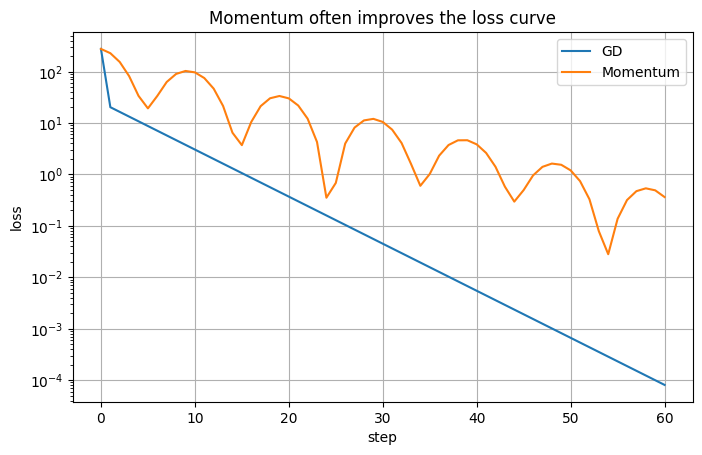

60 步后：
GD       params = [0.      0.00899], loss = 0.000081
Momentum params = [0.19035 0.01979], loss = 0.362712


In [11]:
path_sgd = optimize_path(grad_2d, start=[5, 5], lr=0.05, steps=60, method='sgd')
path_mom = optimize_path(grad_2d, start=[5, 5], lr=0.05, steps=60, method='momentum', beta=0.9)

plt.figure(figsize=(7.5, 6))
plt.contour(Xg, Yg, Z, levels=levels, cmap='viridis')
plt.plot(path_sgd[:, 0], path_sgd[:, 1], 'o-', color='tab:red', markersize=3, label='GD')
plt.plot(path_mom[:, 0], path_mom[:, 1], 'o-', color='tab:blue', markersize=3, label='Momentum')
plt.scatter([0], [0], color='black', s=50, label='minimum')
plt.title('Momentum reduces zig-zag in a narrow valley')
plt.xlabel('x')
plt.ylabel('y')
plt.axis('equal')
plt.legend()
plt.show()

loss_sgd = np.array([f_2d(p) for p in path_sgd])
loss_mom = np.array([f_2d(p) for p in path_mom])

plt.figure(figsize=(8, 4.8))
plt.plot(loss_sgd, label='GD')
plt.plot(loss_mom, label='Momentum')
plt.yscale('log')
plt.xlabel('step')
plt.ylabel('loss')
plt.title('Momentum often improves the loss curve')
plt.legend()
plt.show()

print('60 步后：')
print('GD       params = {}, loss = {:.6f}'.format(np.round(path_sgd[-1], 5), loss_sgd[-1]))
print('Momentum params = {}, loss = {:.6f}'.format(np.round(path_mom[-1], 5), loss_mom[-1]))


## 6. Adam：Momentum + 自适应步长

Adam（Adaptive Moment Estimation）结合了两个思想：

1. **一阶矩 $m_t$**：类似 Momentum，估计梯度的滑动平均。
2. **二阶矩 $v_t$**：估计梯度平方的滑动平均，用来给每个参数自适应缩放步长。

公式如下：

$$
m_t = \beta_1 m_{t-1} + (1-\beta_1)g_t
$$

$$
v_t = \beta_2 v_{t-1} + (1-\beta_2)g_t^2
$$

因为 $m_0=v_0=0$，训练初期的估计会偏向 0，所以 Adam 使用偏差修正：

$$
\hat m_t=\frac{m_t}{1-\beta_1^t},\quad
\hat v_t=\frac{v_t}{1-\beta_2^t}
$$

最后更新：

$$
\theta_t=\theta_{t-1}-\eta\frac{\hat m_t}{\sqrt{\hat v_t}+\epsilon}
$$

常用默认值：$\beta_1=0.9, \beta_2=0.999, \epsilon=10^{-8}$。


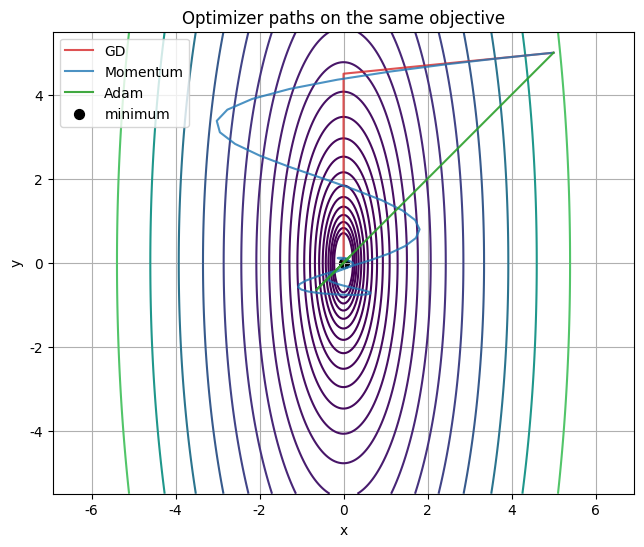

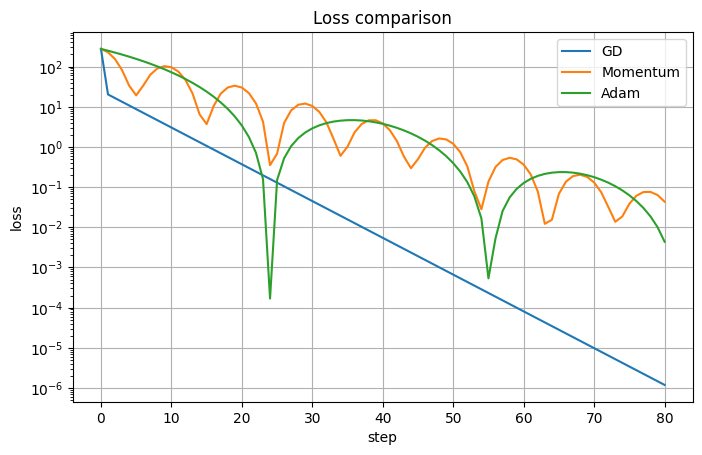

GD        final params=[0.      0.00109], loss=0.00000119
Momentum  final params=[0.06069 0.08081], loss=0.04336214
Adam      final params=[0.01994 0.01994], loss=0.00437570


In [12]:
class Adam:
    """从零实现一个最小版 Adam 优化器。"""
    def __init__(self, lr=0.1, beta1=0.9, beta2=0.999, eps=1e-8):
        self.lr = lr
        self.beta1 = beta1
        self.beta2 = beta2
        self.eps = eps
        self.m = None
        self.v = None
        self.t = 0

    def step(self, params, grads):
        params = np.asarray(params, dtype=float)
        grads = np.asarray(grads, dtype=float)
        if self.m is None:
            self.m = np.zeros_like(params)
            self.v = np.zeros_like(params)
        self.t += 1
        self.m = self.beta1 * self.m + (1 - self.beta1) * grads
        self.v = self.beta2 * self.v + (1 - self.beta2) * (grads ** 2)
        m_hat = self.m / (1 - self.beta1 ** self.t)
        v_hat = self.v / (1 - self.beta2 ** self.t)
        return params - self.lr * m_hat / (np.sqrt(v_hat) + self.eps)

def optimize_adam(grad_fn, start, lr=0.25, steps=80):
    opt = Adam(lr=lr)
    p = np.array(start, dtype=float)
    path = [p.copy()]
    for _ in range(steps):
        p = opt.step(p, grad_fn(p))
        path.append(p.copy())
    return np.array(path)

path_adam = optimize_adam(grad_2d, start=[5, 5], lr=0.25, steps=80)
path_mom_80 = optimize_path(grad_2d, start=[5, 5], lr=0.05, steps=80, method='momentum', beta=0.9)
path_gd_80 = optimize_path(grad_2d, start=[5, 5], lr=0.05, steps=80, method='sgd')

plt.figure(figsize=(7.5, 6))
plt.contour(Xg, Yg, Z, levels=levels, cmap='viridis')
plt.plot(path_gd_80[:, 0], path_gd_80[:, 1], color='tab:red', alpha=0.8, label='GD')
plt.plot(path_mom_80[:, 0], path_mom_80[:, 1], color='tab:blue', alpha=0.8, label='Momentum')
plt.plot(path_adam[:, 0], path_adam[:, 1], color='tab:green', alpha=0.9, label='Adam')
plt.scatter([0], [0], color='black', s=50, label='minimum')
plt.title('Optimizer paths on the same objective')
plt.xlabel('x')
plt.ylabel('y')
plt.axis('equal')
plt.legend()
plt.show()

plt.figure(figsize=(8, 4.8))
for name, path in [('GD', path_gd_80), ('Momentum', path_mom_80), ('Adam', path_adam)]:
    plt.plot([f_2d(p) for p in path], label=name)
plt.yscale('log')
plt.xlabel('step')
plt.ylabel('loss')
plt.title('Loss comparison')
plt.legend()
plt.show()

for name, path in [('GD', path_gd_80), ('Momentum', path_mom_80), ('Adam', path_adam)]:
    print(f"{name:<9} final params={np.round(path[-1], 5)}, loss={f_2d(path[-1]):.8f}")


### 6.1 AdamW：为什么还要 Weight Decay？

实际训练神经网络时，你经常会看到 `AdamW` 而不是 `Adam`。

它解决的是正则化方式的问题。传统 L2 正则会把 $\lambda\theta$ 加进梯度里，但在 Adam 这种自适应优化器中，“加入梯度”和“直接衰减参数”并不等价。

AdamW 的思想是把权重衰减从梯度更新中解耦：

$$
\theta \leftarrow \theta - \eta \cdot \text{AdamStep}(g) - \eta\lambda\theta
$$

直觉上：

- Adam 负责根据梯度找到下降方向；
- weight decay 负责让权重不要无限变大；
- 两者分工明确，所以在 Transformer、LLM 中 AdamW 非常常见。


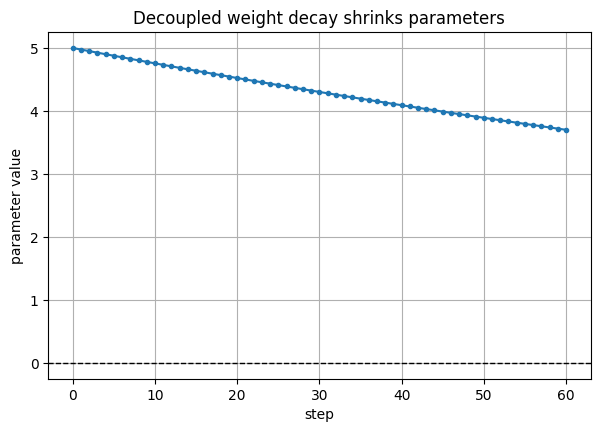

初始参数 5.0，60 步衰减后参数 = 3.7013


In [13]:
# 用一维参数演示 weight decay 的效果：没有数据梯度时，参数会逐步衰减到 0
param = 5.0
lr = 0.1
weight_decay = 0.05
trajectory = [param]

for _ in range(60):
    data_gradient_step = 0.0
    decay_step = lr * weight_decay * param
    param = param - data_gradient_step - decay_step
    trajectory.append(param)

plt.figure(figsize=(7, 4.5))
plt.plot(trajectory, marker='o', markersize=3)
plt.axhline(0, color='black', linestyle='--', linewidth=1)
plt.title('Decoupled weight decay shrinks parameters')
plt.xlabel('step')
plt.ylabel('parameter value')
plt.show()

print('初始参数 5.0，60 步衰减后参数 = {:.4f}'.format(trajectory[-1]))


## 7. 学习率调度：先快跑，后精修

固定学习率并不总是最佳策略。训练常见节奏是：

- 初期：参数离最优点远，需要较大学习率快速移动；
- 后期：接近较好区域，需要较小学习率稳定微调。

常见策略：

1. **Constant LR**：学习率不变，简单 baseline。
2. **Step Decay**：每隔一段时间乘以一个系数，例如 $0.1$。
3. **Exponential Decay**：每一步按指数衰减。
4. **Cosine Annealing**：按余弦曲线从大到小，平滑减速。
5. **Warmup + Cosine**：先从小到大 warmup，再余弦衰减；Transformer/LLM 常用。


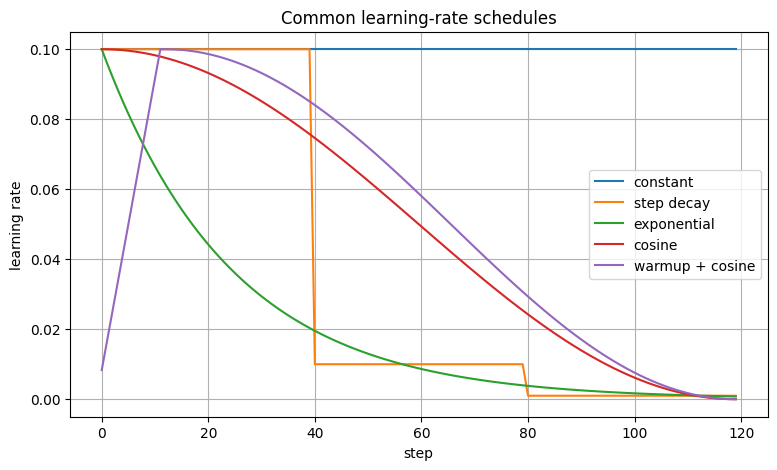

 step         constant       step decay      exponential           cosine  warmup + cosine
--------------------------------------------------------------------------------------------
    0         0.100000         0.100000         0.100000         0.100000         0.008333
    5         0.100000         0.100000         0.081537         0.099565         0.050000
   12         0.100000         0.100000         0.061271         0.097512         0.100000
   40         0.100000         0.010000         0.019537         0.074618         0.084034
   80         0.100000         0.001000         0.003817         0.024242         0.029351
  119         0.100000         0.001000         0.000777         0.000000         0.000000


In [14]:
def make_lr_schedules(n_steps=120, initial_lr=0.1, warmup_steps=12):
    t = np.arange(n_steps)
    constant = np.full(n_steps, initial_lr)
    step_decay = initial_lr * (0.1 ** (t // 40))
    exponential = initial_lr * (0.96 ** t)
    cosine = initial_lr * 0.5 * (1 + np.cos(np.pi * t / (n_steps - 1)))

    warmup_cosine = np.empty(n_steps)
    for i in range(n_steps):
        if i < warmup_steps:
            warmup_cosine[i] = initial_lr * (i + 1) / warmup_steps
        else:
            progress = (i - warmup_steps) / max(1, n_steps - warmup_steps - 1)
            warmup_cosine[i] = initial_lr * 0.5 * (1 + np.cos(np.pi * progress))
    return {
        'constant': constant,
        'step decay': step_decay,
        'exponential': exponential,
        'cosine': cosine,
        'warmup + cosine': warmup_cosine,
    }

schedules = make_lr_schedules()

plt.figure(figsize=(9, 5))
for name, values in schedules.items():
    plt.plot(values, label=name)
plt.xlabel('step')
plt.ylabel('learning rate')
plt.title('Common learning-rate schedules')
plt.legend()
plt.show()

print(f"{'step':>5} " + " ".join([f"{name:>16}" for name in schedules]))
print('-' * 92)
for i in [0, 5, 12, 40, 80, 119]:
    row = f"{i:>5} " + " ".join([f"{values[i]:>16.6f}" for values in schedules.values()])
    print(row)


### 7.1 用调度器优化同一个函数

为了看出调度器的作用，我们把不同学习率序列套到同一个函数上。注意：调度不是魔法，它依赖初始学习率、总步数和目标函数形状。

一个实用经验：

- 如果 loss 一开始就是 NaN 或暴涨，优先降低峰值学习率；
- 如果 loss 稳定但下降很慢，尝试提高学习率或使用 warmup 后更大的峰值；
- 如果后期 loss 抖动大，尝试衰减学习率。


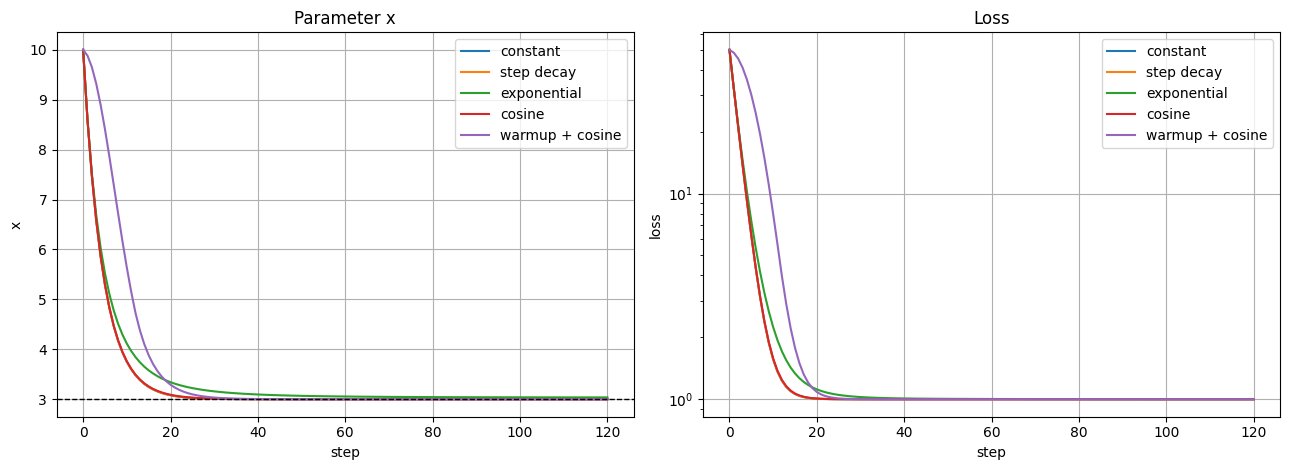

In [15]:
def run_gd_with_schedule(f, grad, x0, lr_values):
    x = float(x0)
    xs = [x]
    losses = [f(x)]
    for lr in lr_values:
        x = x - lr * grad(x)
        xs.append(x)
        losses.append(f(x))
    return np.array(xs), np.array(losses)

schedule_runs = {}
for name, lr_values in schedules.items():
    xs_run, losses_run = run_gd_with_schedule(f_1d, grad_f_1d, x0=10, lr_values=lr_values)
    schedule_runs[name] = (xs_run, losses_run)

fig, axes = plt.subplots(1, 2, figsize=(13, 4.8))
for name, (xs_run, losses_run) in schedule_runs.items():
    axes[0].plot(xs_run, label=name)
    axes[1].plot(losses_run, label=name)
axes[0].axhline(3, color='black', linestyle='--', linewidth=1)
axes[0].set_title('Parameter x')
axes[0].set_xlabel('step')
axes[0].set_ylabel('x')
axes[1].set_title('Loss')
axes[1].set_xlabel('step')
axes[1].set_ylabel('loss')
axes[1].set_yscale('log')
for ax in axes:
    ax.legend()
plt.tight_layout()
plt.show()


## 8. 小项目：从零训练一个线性回归模型

现在把前面的概念串起来：

- 模型：$\hat y = wx+b$
- 损失：均方误差 $\frac{1}{n}\sum_i(\hat y_i-y_i)^2$
- 参数：$w,b$
- 优化器：Mini-batch SGD / Momentum / Adam

为了让比较更直观，我们实现统一的训练循环，然后替换优化器。


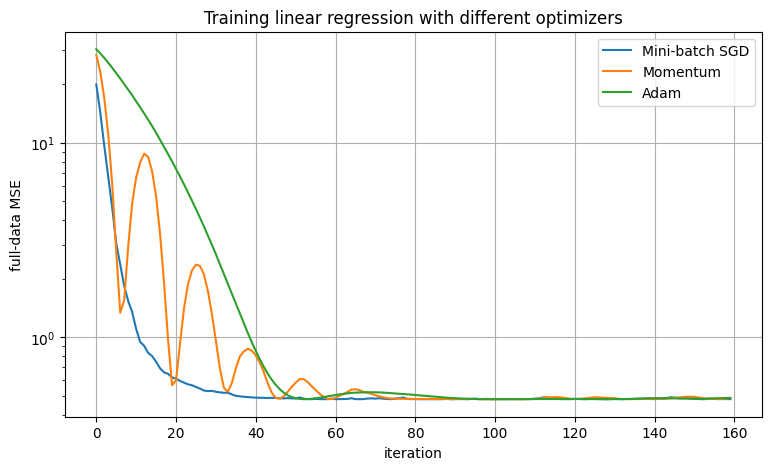

optimizer                w         b       loss
--------------------------------------------------
Mini-batch SGD      2.9894    1.0495     0.4810
Momentum            3.0120    1.0123     0.4870
Adam                2.9583    0.9829     0.4877
真实参数：w=3.0, b=1.0


In [16]:
class SGDOptimizer:
    def __init__(self, lr=0.03):
        self.lr = lr
    def step(self, params, grads):
        return params - self.lr * grads

class MomentumOptimizer:
    def __init__(self, lr=0.03, beta=0.9):
        self.lr = lr
        self.beta = beta
        self.v = None
    def step(self, params, grads):
        if self.v is None:
            self.v = np.zeros_like(params)
        self.v = self.beta * self.v + (1 - self.beta) * grads
        return params - self.lr * self.v

class AdamOptimizer:
    def __init__(self, lr=0.05, beta1=0.9, beta2=0.999, eps=1e-8):
        self.lr = lr
        self.beta1 = beta1
        self.beta2 = beta2
        self.eps = eps
        self.m = None
        self.v = None
        self.t = 0
    def step(self, params, grads):
        if self.m is None:
            self.m = np.zeros_like(params)
            self.v = np.zeros_like(params)
        self.t += 1
        self.m = self.beta1 * self.m + (1 - self.beta1) * grads
        self.v = self.beta2 * self.v + (1 - self.beta2) * grads**2
        m_hat = self.m / (1 - self.beta1**self.t)
        v_hat = self.v / (1 - self.beta2**self.t)
        return params - self.lr * m_hat / (np.sqrt(v_hat) + self.eps)

def train_with_optimizer(X, y, optimizer, steps=160, batch_size=32, seed=0):
    rng = np.random.default_rng(seed)
    params = np.array([0.0, 0.0])  # [w, b]
    losses = []
    params_history = []
    n = len(X)
    for _ in range(steps):
        idx = rng.choice(n, size=batch_size, replace=False)
        Xb, yb = X[idx], y[idx]
        w, b = params
        dw, db = gradient_on_batch(Xb, yb, w, b)
        grads = np.array([dw, db])
        params = optimizer.step(params, grads)
        params_history.append(params.copy())
        losses.append(mse_loss(X, y, params[0], params[1]))
    return np.array(params_history), np.array(losses)

optimizers = {
    'Mini-batch SGD': SGDOptimizer(lr=0.03),
    'Momentum': MomentumOptimizer(lr=0.08, beta=0.9),
    'Adam': AdamOptimizer(lr=0.08),
}

runs = {}
for name, opt in optimizers.items():
    params_hist, losses = train_with_optimizer(X, y, opt, steps=160, batch_size=32, seed=99)
    runs[name] = (params_hist, losses)

plt.figure(figsize=(9, 5))
for name, (_, losses) in runs.items():
    plt.plot(losses, label=name)
plt.yscale('log')
plt.xlabel('iteration')
plt.ylabel('full-data MSE')
plt.title('Training linear regression with different optimizers')
plt.legend()
plt.show()

print(f"{'optimizer':<16} {'w':>9} {'b':>9} {'loss':>10}")
print('-' * 50)
for name, (params_hist, losses) in runs.items():
    w, b = params_hist[-1]
    print(f"{name:<16} {w:>9.4f} {b:>9.4f} {losses[-1]:>10.4f}")
print(f"真实参数：w={w_true}, b={b_true}")


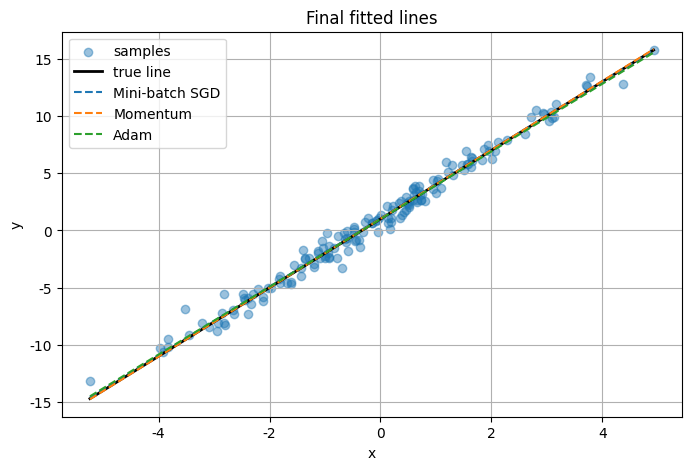

In [17]:
# 观察最终拟合线
plt.figure(figsize=(8, 5))
plt.scatter(X[:, 0], y[:, 0], alpha=0.45, label='samples')
line_x = np.linspace(X.min(), X.max(), 120)
plt.plot(line_x, w_true * line_x + b_true, color='black', linewidth=2, label='true line')

for name, (params_hist, _) in runs.items():
    w, b = params_hist[-1]
    plt.plot(line_x, w * line_x + b, linestyle='--', label=name)

plt.xlabel('x')
plt.ylabel('y')
plt.title('Final fitted lines')
plt.legend()
plt.show()


## 9. 常见误区与排查清单

### 误区 1：loss 不下降一定是模型不行

不一定。先检查优化设置：

- 学习率是否太大导致发散？
- 输入特征是否没有归一化，导致某些方向特别陡？
- 梯度是否写错或忘记除以 batch size？
- 参数是否没有正确更新？

### 误区 2：Adam 总是比 SGD 好

Adam 往往更快、更省调参，但在某些视觉任务中，SGD + Momentum 可能泛化更好。优化器没有绝对赢家，取决于任务、模型、数据和调参预算。

### 误区 3：训练 loss 越低越好

训练 loss 很低但验证 loss 很高，可能是过拟合。优化只负责“把训练目标降下来”，泛化还需要正则化、数据增强、早停等方法。

### 误区 4：batch size 越大越好

大 batch 计算效率高，但可能需要调整学习率和 warmup；batch 太大也可能降低梯度噪声带来的探索性。

## 快速排查清单

1. 先画 loss 曲线：是下降、震荡、发散，还是完全不动？
2. 打印梯度范数：是否为 0、NaN 或极大？
3. 尝试把学习率缩小 10 倍或放大 10 倍。
4. 用一个很小的数据子集做 overfit 测试：模型是否能把训练 loss 降到很低？
5. 检查数据尺度：特征是否需要标准化？


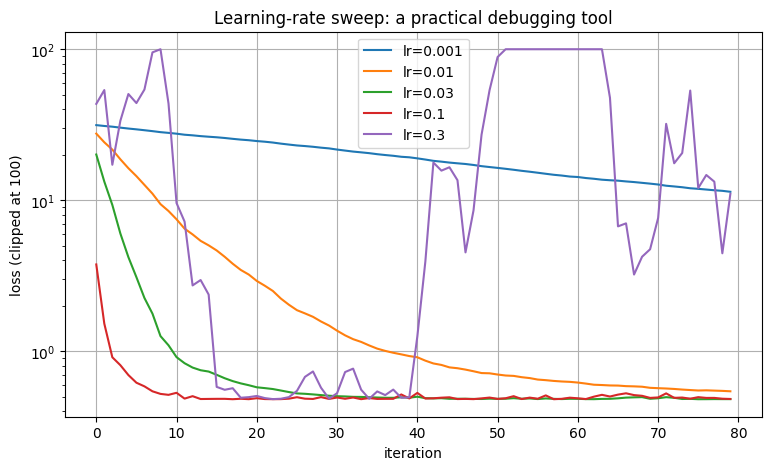

In [18]:
# 一个简单的“学习率诊断图”：同一任务尝试不同学习率
lr_candidates = [0.001, 0.01, 0.03, 0.1, 0.3]
plt.figure(figsize=(9, 5))

for lr in lr_candidates:
    params_hist, losses = train_with_optimizer(
        X, y, SGDOptimizer(lr=lr), steps=80, batch_size=32, seed=2024
    )
    # 截断极端值只是为了让图更易读
    plt.plot(np.minimum(losses, 100), label=f'lr={lr}')

plt.yscale('log')
plt.xlabel('iteration')
plt.ylabel('loss (clipped at 100)')
plt.title('Learning-rate sweep: a practical debugging tool')
plt.legend()
plt.show()


## 10. 本节总结与练习

### 核心总结

1. 优化的目标是找到使损失函数最小的参数。
2. 梯度下降沿负梯度方向更新参数。
3. 学习率决定步长：太小慢，太大震荡或发散。
4. Mini-batch SGD 是计算效率和梯度稳定性的折中。
5. Momentum 通过累积速度减少震荡、加速一致方向。
6. Adam 结合一阶矩、二阶矩和偏差修正，是深度学习中常用的默认优化器。
7. 学习率调度让训练“先快后慢”，在大模型训练中尤其重要。
8. 优化器只能降低目标函数；泛化能力还需要验证集、正则化和数据策略共同保证。

### 建议练习

1. 把 §3 中的一维函数换成 $f(x)=x^4-3x^3+2$，观察不同初始点会到哪里。
2. 在 §4 中把 batch size 改成 2、8、128，比较梯度噪声和收敛速度。
3. 在 §5 中尝试 $\beta=0.5,0.9,0.99$，观察 Momentum 路径变化。
4. 修改 §6 中 Adam 的 $\beta_1,\beta_2$，看看过大或过小会发生什么。
5. 给 §8 的线性回归加上特征标准化，再比较不同学习率能否使用更大的值。

下一节进入 Python AI 工具库时，你会看到这些优化思想如何出现在 NumPy、PyTorch 或其他机器学习框架中。
